In [17]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin

In [18]:
def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until pyproject.toml is found."""
    current = (start or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find project root containing pyproject.toml"
    )


ROOT = find_project_root()
IBM_TRAINING = ROOT / "share_IBM_training"
OPTICAL_DATA = ROOT / "Optical_Axis_Alignment_Data"

DATA_DIR = ROOT / "processed"

DATA_DIR

WindowsPath('C:/Users/BS01493/Projects/SBU Europe/Client/GigaAI/Client Data - v3/data/processed')

In [19]:
AMP_SUMMARY_KEEP = [
    "AMP HV","OSC HV","Energy","OSC Energy",
    "BD Size Hor","BD Size Ver","BD COG Hor","BD COG Ver",
    "BP Size Hor","BP Size Ver","BP ContM Hor","BP ContM Ver",
    "Energy Sigma","Dose Max","Dose min","Dose R","Dose U",
    "Wavelength Ave Max","Wavelength Ave min","Wavelength Sigma Max", "Total_Score",
    # "AFM H Adjustment Amount","AFM V Adjustment Amount",
    # "AFM x centroid","AFM y centroid", 
]

OSC_SUMMARY_KEEP = [
    "AMP HV","OSC HV","Energy","OSC Energy",
    "BD Size Hor","BD Size Ver","BD COG Hor","BD COG Ver",
    "BP Size Hor","BP Size Ver","BP ContM Hor","BP ContM Ver",
    "Energy Sigma","Dose Max","Dose min","Dose R","Dose U",
    "Wavelength Ave Max","Wavelength Ave min","Wavelength Sigma Max", "Total_Score"
    # "OBS Upper H Adjustment Amount","OBS Upper V Adjustment Amount",
    # "OBS Lower H Adjustment Amount","OBS Lower V Adjustment Amount",
    # "OBS Upper x centroid","OBS Upper y centroid",
]

In [20]:
def build_dataset(
    beam_path,
    summary_path,
    keep_cols,
):
    beam = pd.read_csv(beam_path)
    summary = pd.read_csv(summary_path)

    assert len(beam) == len(summary)

    summary_feats = summary[[c for c in keep_cols if c in summary.columns]].copy()

    for col in summary_feats.columns:
        summary_feats[col] = summary_feats[col].fillna(
            summary_feats[col].median()
        )

    final_df = pd.concat(
        [
            summary[["Laser", "No", "Rank"]],
            beam,
            summary_feats,
        ],
        axis=1,
    )
    
    final_df = final_df[final_df["Rank"] != "E"]
    return final_df.drop(columns=["Rank"])

In [21]:
amp = build_dataset(
    DATA_DIR / "beam_physical_feature_amp.csv",
    IBM_TRAINING / "AMP_summary.csv",
    AMP_SUMMARY_KEEP,
)

amp.shape

(232, 200)

In [22]:
osc = build_dataset(
    DATA_DIR / "beam_physical_feature_osc.csv",
    IBM_TRAINING / "OSC_summary.csv",
    OSC_SUMMARY_KEEP,
)

osc.shape

(204, 200)

In [23]:
class VarianceCorrelationFilter(BaseEstimator, TransformerMixin):
    """
    A generic scikit-learn transformer to filter out low-variance features 
    and highly correlated feature pairs from a pandas DataFrame, optimized for high-dimensional data.
    """
    def __init__(self, var_threshold=1e-6, corr_threshold=0.97):
        self.var_threshold = var_threshold
        self.corr_threshold = corr_threshold
        self.kept_cols_ = []
        
        # Internal state saved for visualization purposes
        self.high_var_cols_ = []
        self.corr_matrix_ = None
        self.drop_cols_ = []

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        # -------------------------
        # Stage 1: Variance Filter
        # -------------------------
        variances = X.var(numeric_only=True)
        self.high_var_cols_ = [c for c in X.columns if variances.get(c, 0) >= self.var_threshold]
        
        if not self.high_var_cols_:
            self.kept_cols_ = []
            return self

        # -------------------------
        # Stage 2: Correlation Filter
        # -------------------------
        self.corr_matrix_ = X[self.high_var_cols_].corr().abs()
        
        upper_tri = self.corr_matrix_.where(np.triu(np.ones(self.corr_matrix_.shape), k=1).astype(bool))
        self.drop_cols_ = [column for column in upper_tri.columns if any(upper_tri[column] > self.corr_threshold)]
        
        self.kept_cols_ = [c for c in self.high_var_cols_ if c not in self.drop_cols_]
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X[self.kept_cols_]

    def visualize_correlations(self, top_n=20):
        """
        Extracts and displays a clean list of the top N highest correlated feature pairs.
        """
        if self.corr_matrix_ is None:
            raise ValueError("The transformer must be fitted (`.fit()`) before visualizing.")
            
        # Get the upper triangle mask to avoid duplicate pairs (A-B and B-A) and self-correlation (A-A)
        upper_tri = np.triu(np.ones_like(self.corr_matrix_, dtype=bool), k=1)
        
        # Flatten the matrix into a tidy Series of pairs
        corr_pairs = self.corr_matrix_.where(upper_tri).stack()
        
        # Convert to a DataFrame and sort by absolute correlation descending
        corr_df = corr_pairs.reset_index()
        corr_df.columns = ['Feature 1', 'Feature 2', 'Correlation']
        corr_df = corr_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True)
        
        # Add tracking to show which columns are being dropped by the filter
        corr_df['Action'] = corr_df.apply(
            lambda row: f"Drop {row['Feature 2']}" if row['Feature 2'] in self.drop_cols_ 
            else (f"Drop {row['Feature 1']}" if row['Feature 1'] in self.drop_cols_ else "Keep Both"),
            axis=1
        )
        
        # Get the top N rows
        top_corrs = corr_df.head(top_n)
        
        # Display results cleanly using pandas styling
        print(f"\n=== TOP {top_n} HIGHEST CORRELATIONS ===")
        print(f"Current Filter Threshold: {self.corr_threshold}\n")
        
        # Beautiful console or Jupyter notebook formatting
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)
        print(top_corrs.to_string(index=True, formatters={'Correlation': '{:,.4f}'.format}))
        
        return top_corrs

In [24]:
feature_filter = VarianceCorrelationFilter(var_threshold=1e-6, corr_threshold=0.95)
amp = feature_filter.fit_transform(amp)

In [25]:
feature_filter = VarianceCorrelationFilter(var_threshold=1e-6, corr_threshold=0.95)
osc = feature_filter.fit_transform(osc)

In [26]:
amp.shape, osc.shape

((232, 97), (204, 105))

---
## K-Means Clustering (k=3)

We cluster the `amp` and `osc` datasets separately into **3 groups** using K-Means on all numeric features (excluding `Total_Score` and ID columns).  
After clustering we:
1. Report the **average `Total_Score`** per cluster.
2. Produce a **feature importance / similarity report** based on the between-cluster variance ratio (F-statistic proxy), which indicates how strongly each feature separates the clusters.

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import silhouette_score
from scipy import stats

In [28]:
# ── Utility helpers ──────────────────────────────────────────────────────────

ID_COLS = ["Laser", "No"]   # non-feature identifier columns
RANDOM_STATE = 42

def find_best_k_silhouette(df: pd.DataFrame, col_name: str = "Total_Score", max_k: int = 6, title_prefix: str = "AMP") -> int:
    """
    Perform Silhouette Analysis on a 1D column (e.g. Total_Score) to find the best K.
    """
    X = df[[col_name]].dropna().values
    k_values = list(range(2, max_k + 1))
    scores = []
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
        
    best_k = k_values[np.argmax(scores)]
    best_score = max(scores)
    
    # Plot Silhouette Scores
    plt.figure(figsize=(6, 3.5))
    plt.plot(k_values, scores, 'bo-', color='#2980b9', linewidth=2)
    plt.xlabel('Number of Clusters (k)', fontsize=11)
    plt.ylabel('Silhouette Score', fontsize=11)
    plt.title(f'{title_prefix} - Silhouette Analysis for {col_name}', fontsize=12, fontweight='bold')
    plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k} (Score: {best_score:.3f})')
    plt.legend(fontsize=9)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    print(f"Optimal K for {title_prefix} based on Silhouette Analysis: {best_k} (Score: {best_score:.4f})")
    return best_k

def cluster_by_score_and_get_thresholds(df: pd.DataFrame, best_k: int, col_name: str = "Total_Score", title_prefix: str = "AMP") -> tuple:
    """
    Cluster df by score column, map labels in ascending order of score, and print boundary thresholds.
    """
    X = df[[col_name]].dropna().values
    kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto")
    labels = kmeans.fit_predict(X)
    
    df_clustered = df.copy()
    df_clustered["Score_Cluster"] = labels
    
    # Sort cluster labels ascendingly based on mean score (0 = lowest score group, best_k-1 = highest)
    cluster_means = df_clustered.groupby("Score_Cluster")[col_name].mean().sort_values()
    rank_map = {old_label: new_label for new_label, old_label in enumerate(cluster_means.index)}
    df_clustered["Score_Cluster"] = df_clustered["Score_Cluster"].map(rank_map)
    
    # Print cluster thresholds
    summary = df_clustered.groupby("Score_Cluster")[col_name].agg(
        Count="count",
        Min="min",
        Max="max",
        Mean="mean",
        Std="std"
    ).reset_index()
    
    print(f"\n=== {title_prefix} | Score Clusters & Threshold Boundaries ===")
    print(summary.to_string(index=False))
    return df_clustered, summary

def _prepare_feature_matrix(df: pd.DataFrame) -> tuple:
    """
    Shared feature-selection + scaling logic used by both feature-space
    silhouette analysis and run_kmeans, so the two always operate on
    the identical matrix.
    """
    drop_cols = ID_COLS + ["Total_Score"]
    feat_cols = [
        c for c in df.select_dtypes(include="number").columns
        if c not in drop_cols
    ]

    X = df[feat_cols].fillna(df[feat_cols].median())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, scaler, feat_cols


def find_best_k_silhouette_features(df: pd.DataFrame, max_k: int = 6, title_prefix: str = "AMP") -> int:
    """
    Perform Silhouette Analysis on the standardized FEATURE MATRIX
    (not on Total_Score) to find the best K for feature-based clustering.
    Uses the same feature selection / scaling as run_kmeans, so the
    resulting k is valid for that clustering problem.
    """
    X_scaled, _, feat_cols = _prepare_feature_matrix(df)

    k_values = list(range(2, max_k + 1))
    scores = []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores.append(score)

    best_k = k_values[np.argmax(scores)]
    best_score = max(scores)

    plt.figure(figsize=(6, 3.5))
    plt.plot(k_values, scores, 'bo-', color='#2980b9', linewidth=2)
    plt.xlabel('Number of Clusters (k)', fontsize=11)
    plt.ylabel('Silhouette Score', fontsize=11)
    plt.title(f'{title_prefix} - Silhouette Analysis on Feature Matrix ({len(feat_cols)} features)',
              fontsize=12, fontweight='bold')
    plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k} (Score: {best_score:.3f})')
    plt.legend(fontsize=9)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print(f"Optimal K for {title_prefix} feature-space clustering: {best_k} (Score: {best_score:.4f})")
    if best_score < 0.25:
        print(f"  ⚠ Silhouette score is low ({best_score:.3f}) — clusters in feature space are weak/overlapping.")
    return best_k


def run_kmeans(df: pd.DataFrame, n_clusters: int) -> tuple:
    """
    Fit K-Means on numeric features (excl. Total_Score & ID cols) with dynamic K.
    """
    X_scaled, scaler, feat_cols = _prepare_feature_matrix(df)

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)

    df_out = df.copy()
    df_out["Cluster"] = labels
    return df_out, scaler, kmeans, feat_cols

def cluster_score_summary(df_clustered: pd.DataFrame) -> pd.DataFrame:
    """Average Total_Score and cluster size per cluster."""
    summary = (
        df_clustered
        .groupby("Cluster")["Total_Score"]
        .agg(Count="count", Mean_Total_Score="mean", Std_Total_Score="std", Max_Total_Score="max", Min_Total_Score="min")
        .reset_index()
        .sort_values("Mean_Total_Score", ascending=False)
    )
    return summary

def feature_importance_report(df_clustered: pd.DataFrame, feat_cols: list, top_n: int = 15) -> pd.DataFrame:
    records = []
    for col in feat_cols:
        groups = [
            grp[col].dropna().values
            for _, grp in df_clustered.groupby("Cluster")
        ]
        if all(len(g) >= 2 for g in groups):
            f_stat, p_val = stats.f_oneway(*groups)
        else:
            f_stat, p_val = np.nan, np.nan

        cluster_means = [g.mean() for g in groups if len(g) > 0]
        spread = np.std(cluster_means) if cluster_means else np.nan

        records.append(
            {
                "Feature": col,
                "F_statistic": round(f_stat, 4) if not np.isnan(f_stat) else np.nan,
                "p_value": round(p_val, 6) if not np.isnan(p_val) else np.nan,
                "Cluster_Mean_Spread": round(spread, 4),
                "Importance": "High" if (not np.isnan(f_stat) and f_stat > 10) else "Low",
            }
        )

    report = (
        pd.DataFrame(records)
        .sort_values("F_statistic", ascending=False)
        .reset_index(drop=True)
    )
    return report.head(top_n)

def plot_cluster_scores(summary: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#54B3E0"]
    ax.bar(
        summary["Cluster"].astype(str),
        summary["Mean_Total_Score"],
        yerr=summary["Std_Total_Score"],
        color=colors[: len(summary)],
        capsize=5,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.set_xlabel("Cluster", fontsize=12)
    ax.set_ylabel("Mean Total Score", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    for i, row in summary.iterrows():
        ax.text(
            str(row["Cluster"]),
            row["Mean_Total_Score"] + row["Std_Total_Score"] + 0.005,
            f"n={int(row['Count'])}",
            ha="center",
            fontsize=9,
        )
    plt.tight_layout()
    plt.show()

def plot_feature_importance(report: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, max(4, len(report) * 0.45)))
    colors = ["#c0392b" if imp == "High" else "#2980b9" for imp in report["Importance"]]
    ax.barh(
        report["Feature"][::-1],
        report["F_statistic"][::-1],
        color=colors[::-1],
        edgecolor="black",
        linewidth=0.6,
    )
    ax.set_xlabel("ANOVA F-Statistic (higher = more cluster separation)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axvline(10, color="grey", linestyle="--", linewidth=0.9, label="F=10 threshold")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


### AMP — K-Means Clustering

C:\Users\BS01493\AppData\Local\Temp\ipykernel_20056\616051226.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(k_values, scores, 'bo-', color='#2980b9', linewidth=2)


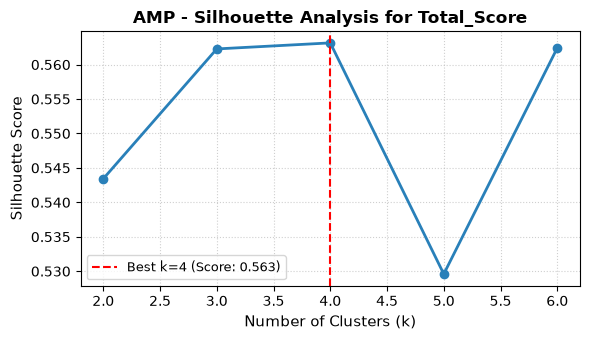

Optimal K for AMP based on Silhouette Analysis: 4 (Score: 0.5632)

=== AMP | Score Clusters & Threshold Boundaries ===
 Score_Cluster  Count   Min   Max      Mean      Std
             0     29 22.25 41.00 33.439655 4.878275
             1     76 41.75 54.00 48.983553 3.534670
             2     75 55.00 65.25 59.390000 2.849917
             3     52 65.75 84.00 71.850962 5.173049


C:\Users\BS01493\AppData\Local\Temp\ipykernel_20056\616051226.py:108: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(k_values, scores, 'bo-', color='#2980b9', linewidth=2)


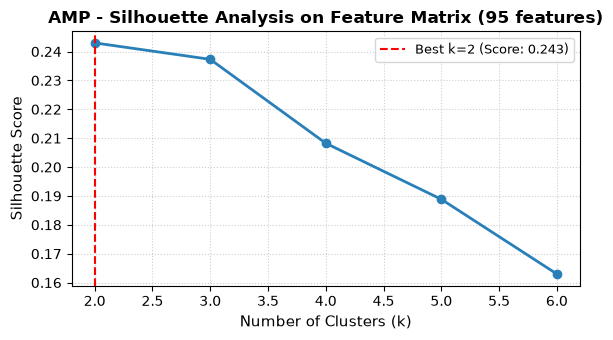

Optimal K for AMP feature-space clustering: 2 (Score: 0.2430)
  ⚠ Silhouette score is low (0.243) — clusters in feature space are weak/overlapping.

=== AMP  |  Cluster Score Summary (Feature-based clustering) ===


,Cluster,Count,Mean_Total_Score,Std_Total_Score,Max_Total_Score,Min_Total_Score
1,1,105,55.964286,12.506221,84.0,22.25
0,0,127,55.171260,12.486290,84.0,24.00


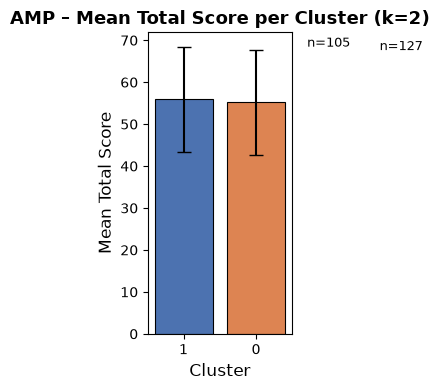

In [29]:
# 1. Find optimal K for AMP score thresholds (1D, score-space)
best_k_amp_score = find_best_k_silhouette(amp, col_name="Total_Score", title_prefix="AMP")

# 2. Get Score Thresholds/Boundaries via 1D Clustering
amp_score_clustered, amp_thresholds = cluster_by_score_and_get_thresholds(amp, best_k_amp_score, title_prefix="AMP")

# 3. Find optimal K for AMP feature-based clustering (separate problem, separate k)
best_k_amp_feat = find_best_k_silhouette_features(amp, title_prefix="AMP")

# 4. Run feature-based clustering using the feature-space-appropriate K
amp_clustered, amp_scaler, amp_kmeans, amp_feat_cols = run_kmeans(amp, n_clusters=best_k_amp_feat)

# ── Cluster sizes & average Total_Score ─────────────────────────────────────
amp_score_summary = cluster_score_summary(amp_clustered)
print("\n=== AMP  |  Cluster Score Summary (Feature-based clustering) ===")
display(amp_score_summary)

plot_cluster_scores(amp_score_summary, f"AMP – Mean Total Score per Cluster (k={best_k_amp_feat})")

=== AMP  |  Top-15 Features by Cluster Separation (ANOVA F-Statistic) ===


,Feature,F_statistic,p_value,Cluster_Mean_Spread,Importance
0,BD_bg_level,2776.8800,0.0,29.1714,High
1,BP_bg_level,2146.4609,0.0,34.5138,High
2,BP_p90_to_mean,1315.0292,0.0,0.2247,High
3,BP_gauss_sigma_x,1153.0221,0.0,0.0014,High
4,BP_zone_0_3_std,1137.6987,0.0,1.6194,High
5,BP_global_p90,1083.6709,0.0,46.5456,High
6,BD_edge_asymmetry_h,1050.5486,0.0,0.0017,High
7,BD_iso_centroid_x,1025.5515,0.0,0.0124,High
8,session_id,669.8199,0.0,66.8079,High
9,BD_iso_centroid_y,624.2622,0.0,0.0127,High


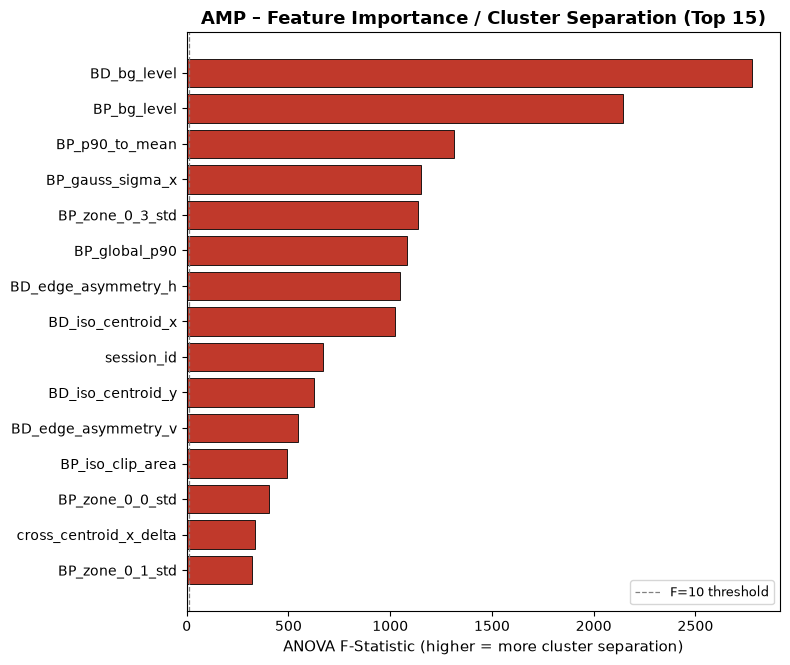

In [30]:
# ── Feature importance / similarity report ───────────────────────────────────
amp_feat_report = feature_importance_report(amp_clustered, amp_feat_cols, top_n=15)
print("=== AMP  |  Top-15 Features by Cluster Separation (ANOVA F-Statistic) ===")
display(amp_feat_report)

plot_feature_importance(amp_feat_report, "AMP – Feature Importance / Cluster Separation (Top 15)")

### OSC — K-Means Clustering

C:\Users\BS01493\AppData\Local\Temp\ipykernel_20056\616051226.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(k_values, scores, 'bo-', color='#2980b9', linewidth=2)


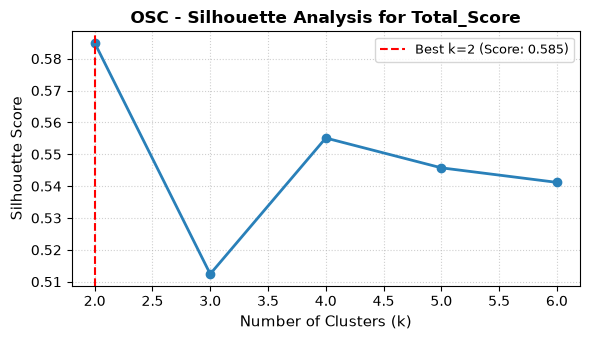

Optimal K for OSC based on Silhouette Analysis: 2 (Score: 0.5850)

=== OSC | Score Clusters & Threshold Boundaries ===
 Score_Cluster  Count   Min   Max      Mean      Std
             0     93 24.00 54.75 44.322581 7.761263
             1    111 55.25 89.25 65.565315 7.191829

=== OSC  |  Cluster Score Summary (Feature-based clustering) ===


,Cluster,Count,Mean_Total_Score,Std_Total_Score,Max_Total_Score,Min_Total_Score
0,0,128,57.865234,12.960490,89.25,25.0
1,1,76,52.539474,12.318418,77.75,24.0


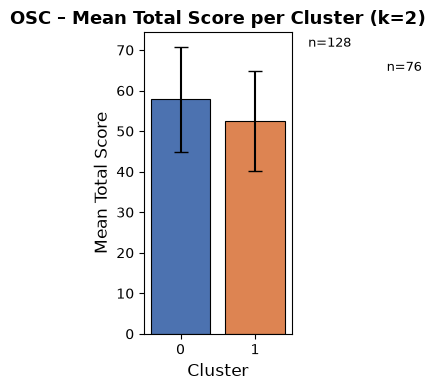

In [31]:
# 1. Find optimal K for OSC dynamically
best_k_osc = find_best_k_silhouette(osc, col_name="Total_Score", title_prefix="OSC")
# 2. Get Score Thresholds/Boundaries via 1D Clustering
osc_score_clustered, osc_thresholds = cluster_by_score_and_get_thresholds(osc, best_k_osc, title_prefix="OSC")
# 3. Run feature-based clustering using optimal K
osc_clustered, osc_scaler, osc_kmeans, osc_feat_cols = run_kmeans(osc, n_clusters=best_k_osc)
# ── Cluster sizes & average Total_Score ─────────────────────────────────────
osc_score_summary = cluster_score_summary(osc_clustered)
print("\n=== OSC  |  Cluster Score Summary (Feature-based clustering) ===")
display(osc_score_summary)
plot_cluster_scores(osc_score_summary, f"OSC – Mean Total Score per Cluster (k={best_k_osc})")

=== OSC  |  Top-15 Features by Cluster Separation (ANOVA F-Statistic) ===


,Feature,F_statistic,p_value,Cluster_Mean_Spread,Importance
0,BP_edge_asymmetry_h,3422.9911,0.0,0.0011,High
1,BD_iso_centroid_x,2703.3474,0.0,0.0119,High
2,BD_iso_centroid_y,1164.8527,0.0,0.0134,High
3,BD_sym_vertical,939.0937,0.0,0.1187,High
4,BD_zone_1_1_mean,628.2680,0.0,10.4690,High
5,BD_iso_d_minor,473.4569,0.0,0.0389,High
6,BD_sym_q3,389.9556,0.0,0.0461,High
7,session_id,342.4488,0.0,64.9431,High
8,BD_marginal_skew_x,328.5010,0.0,0.4614,High
9,BP_zone_0_0_std,289.7329,0.0,0.4978,High


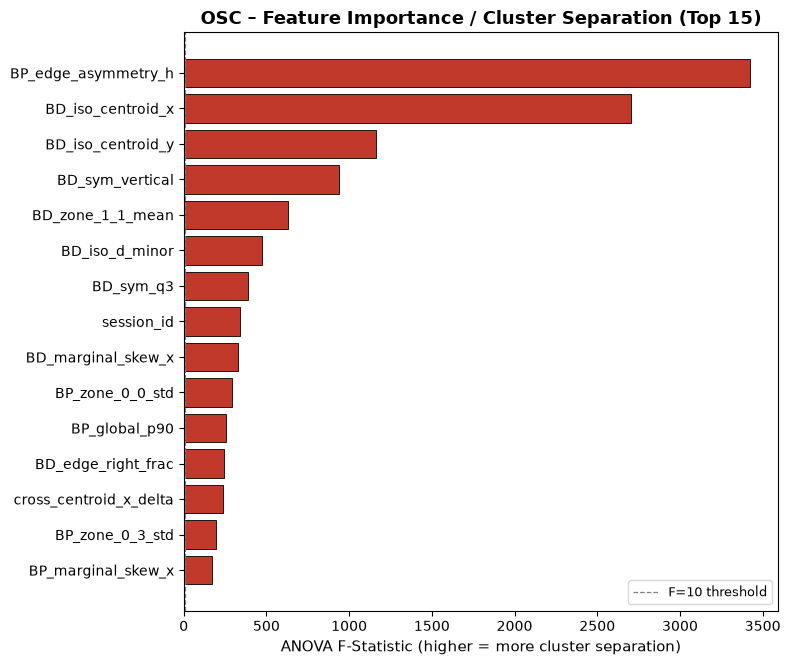

In [32]:
# ── Feature importance / similarity report ───────────────────────────────────
osc_feat_report = feature_importance_report(osc_clustered, osc_feat_cols, top_n=15)
print("=== OSC  |  Top-15 Features by Cluster Separation (ANOVA F-Statistic) ===")
display(osc_feat_report)

plot_feature_importance(osc_feat_report, "OSC – Feature Importance / Cluster Separation (Top 15)")